# Group Project
Time Series Analysis of Hanoi Food CPI & Anomaly/Change-Point Detection in
Asian Economic Data (Myanmar).

This notebook is designed to run top-to-bottom in **Google Colab**. Upload
`Data01_01_FoodCPI.csv` and `Data02_01_Myanmar_C.csv` to `/content/` (or the
Colab file browser) before running, or simply run the first code cell which
will look in `/content/` first and fall back to the local working directory.

Course-specific methodology (trend test, ADF rule, AIC+CI stability rule,
Z-score threshold, Isolation Forest settings, change-point settings) follows
`course_methodology.md`, extracted from the course lecture slides.

# Libraries and Configuration

In [1]:
# If running in Colab, uncomment the line below to install any missing packages:
# !pip install -q statsmodels ruptures scikit-learn

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error

import ruptures as rpt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

FIG_DIR = "figures"
RESULTS_DIR = "results"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Environment ready. Random seed fixed at", RANDOM_STATE)

Environment ready. Random seed fixed at 42


# Data Loading

In [2]:
def resolve_path(fname):
    """Prefer /content/<fname> (Colab upload target); fall back to local dir."""
    content_path = os.path.join("/content", fname)
    if os.path.exists(content_path):
        return content_path
    return fname

PATH_DATA1 = resolve_path("Data01_01_FoodCPI.csv")
PATH_DATA2 = resolve_path("Data02_01_Myanmar_C.csv")

df1 = pd.read_csv(PATH_DATA1)
df2 = pd.read_csv(PATH_DATA2)

print("Loaded:", PATH_DATA1, "->", df1.shape)
print("Loaded:", PATH_DATA2, "->", df2.shape)

Loaded: Data01_01_FoodCPI.csv -> (96, 6)
Loaded: Data02_01_Myanmar_C.csv -> (32, 7)


# Data Validation

## Data01_01_FoodCPI.csv (Hanoi Food CPI, monthly)

In [3]:
print("Shape:", df1.shape)
print("\nColumn names:", list(df1.columns))
print("\nDtypes:\n", df1.dtypes)
print("\nFirst rows:")
display(df1.head())
print("\nDescriptive statistics:")
display(df1.describe())
print("\nMissing values per column:\n", df1.isna().sum())
print("\nDuplicate rows:", df1.duplicated().sum())
print("\nYear coverage:", df1['Year'].min(), "-", df1['Year'].max())
print("Rows per year:\n", df1.groupby('Year').size())

Shape: (96, 6)

Column names: ['Time', 'Year', 'Month', 'FoodCPItoDec', 'CPI_toPM', 'CPI_rate']

Dtypes:
 Time              int64
Year              int64
Month             int64
FoodCPItoDec    float64
CPI_toPM        float64
CPI_rate        float64
dtype: object

First rows:


,Time,Year,Month,FoodCPItoDec,CPI_toPM,CPI_rate
0,1,2015,1,100.0,100.000000,0.000000
1,2,2015,2,100.1,100.100000,0.100000
2,3,2015,3,100.2,100.099900,0.099900
3,4,2015,4,99.5,99.301397,-0.698603
4,5,2015,5,98.9,99.396985,-0.603015



Descriptive statistics:


,Time,Year,Month,FoodCPItoDec,CPI_toPM,CPI_rate
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,48.500000,2018.500000,6.500000,100.154792,100.033545,0.033545
std,27.856777,2.303316,3.470174,0.730151,0.836829,0.836829
min,1.000000,2015.000000,1.000000,96.100000,96.582915,-3.417085
25%,24.750000,2016.750000,3.750000,99.827500,99.601666,-0.398334
50%,48.500000,2018.500000,6.500000,100.190000,100.055045,0.055045
75%,72.250000,2020.250000,9.250000,100.500000,100.404664,0.404664
max,96.000000,2022.000000,12.000000,102.600000,103.954214,3.954214



Missing values per column:
 Time            0
Year            0
Month           0
FoodCPItoDec    0
CPI_toPM        0
CPI_rate        0
dtype: int64

Duplicate rows: 0

Year coverage: 2015 - 2022
Rows per year:
 Year
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
dtype: int64


In [4]:
# Build a proper monthly Date index and confirm chronological ordering
df1["Date"] = pd.to_datetime(df1["Year"].astype(str) + "-" + df1["Month"].astype(str) + "-01")
df1 = df1.sort_values("Date").reset_index(drop=True)
assert df1["Date"].is_monotonic_increasing, "Data01 is not chronologically ordered!"
print("Data01 is chronologically ordered:", df1["Date"].is_monotonic_increasing)
print("Date range:", df1['Date'].min().date(), "to", df1['Date'].max().date())

Data01 is chronologically ordered: True
Date range: 2015-01-01 to 2022-12-01


### Column mapping (Data01 -> Template series)

The teacher template requires analysis of **Series 1 (CPI)** and **Series 3 (CPI
rate)**. The CSV column names do not exactly match the template wording, so the
mapping used throughout this notebook is:

| Template series | CSV column       | Meaning                                   |
|---|---|---|
| Series 1 (CPI)      | `FoodCPItoDec` | Food CPI index, base = Dec (first month)  |
| Series 2 (not required) | `CPI_toPM` | CPI relative to previous month (not used) |
| Series 3 (CPI rate) | `CPI_rate`     | Month-over-month % change in CPI          |

No values in the raw CSV are altered; only a `Date` column is added for
plotting/indexing.

In [5]:
SERIES1_COL = "FoodCPItoDec"   # Series 1 - CPI
SERIES3_COL = "CPI_rate"       # Series 3 - CPI rate

cpi = df1[SERIES1_COL].copy()
cpi_rate = df1[SERIES3_COL].copy()
print("CPI (Series 1) head:\n", cpi.head())
print("\nCPI rate (Series 3) head:\n", cpi_rate.head())

CPI (Series 1) head:
 0    100.0
1    100.1
2    100.2
3     99.5
4     98.9
Name: FoodCPItoDec, dtype: float64

CPI rate (Series 3) head:
 0    0.000000
1    0.100000
2    0.099900
3   -0.698603
4   -0.603015
Name: CPI_rate, dtype: float64


## Data02_01_Myanmar_C.csv (Myanmar annual economic indicators)

In [6]:
print("Shape:", df2.shape)
print("\nColumn names:", list(df2.columns))
print("\nDtypes:\n", df2.dtypes)
print("\nFirst rows:")
display(df2.head())
print("\nDescriptive statistics:")
display(df2.describe())
print("\nMissing values per column:\n", df2.isna().sum())
print("\nDuplicate rows:", df2.duplicated().sum())
print("\nYear coverage:", df2['year'].min(), "-", df2['year'].max())
print("\nCountries present:", df2['country'].unique())

Shape: (32, 7)

Column names: ['year', 'country', 'ggdp', 'mil', 'inf', 'fdi', 'gdp']

Dtypes:
 year         int64
country        str
ggdp       float64
mil        float64
inf        float64
fdi        float64
gdp          int64
dtype: object

First rows:


,year,country,ggdp,mil,inf,fdi,gdp
0,1990,Myanmar,4.500000e+09,0.863495,17.626775,161144560.3,2036373523
1,1991,Myanmar,4.700000e+09,0.765301,32.272038,238056791.9,2137184858
2,1992,Myanmar,4.800000e+09,0.730921,21.913210,171558720.0,2216072577
3,1993,Myanmar,5.300000e+09,0.707610,31.831607,104674233.1,2809748387
4,1994,Myanmar,5.700000e+09,0.765310,24.098786,126091858.5,3821535780



Descriptive statistics:


,year,ggdp,mil,inf,fdi,gdp
count,32.000000,3.000000e+01,25.000000,30.000000,3.200000e+01,3.200000e+01
mean,2005.500000,2.795333e+10,2.378354,18.070240,1.106545e+09,2.828462e+10
std,9.380832,2.652991e+10,1.241858,14.768483,1.238266e+09,2.738741e+10
min,1990.000000,4.500000e+09,0.707610,-0.109166,1.046742e+08,2.036374e+09
25%,1997.750000,6.225000e+09,1.354601,5.950361,2.372687e+08,5.641132e+09
50%,2005.500000,1.045000e+10,2.008901,16.951086,3.508176e+08,1.122572e+10
75%,2013.250000,5.800000e+10,3.523109,26.398331,1.802935e+09,6.036187e+10
max,2021.000000,7.400000e+10,4.301367,57.074511,4.804272e+09,7.893026e+10



Missing values per column:
 year       0
country    0
ggdp       2
mil        7
inf        2
fdi        0
gdp        0
dtype: int64

Duplicate rows: 0

Year coverage: 1990 - 2021

Countries present: <StringArray>
['Myanmar']
Length: 1, dtype: str


### Column mapping (Data02 -> Template series)

Template requires five series: **ggdp, mil, inf, fdi, gdp**. These map directly
onto the CSV columns of the same name (`ggdp`, `mil`, `inf`, `fdi`, `gdp`) — no
renaming needed. `mil` has missing values for several years (7 in total),
`ggdp` and `inf` each have 2 missing years. These are **not imputed**: each
series is analyzed on its own available (non-missing) years, with the
corresponding `year`/`country` kept alongside every value so anomalies/change
points can be traced back to a real observation.

In [7]:
PART2_SERIES = ["ggdp", "mil", "inf", "fdi", "gdp"]
print("Missing values per Part-2 series:")
print(df2[PART2_SERIES].isna().sum())

data_summary = pd.DataFrame([
    {"dataset": "Data01_01_FoodCPI.csv", "rows": df1.shape[0], "cols": df1.shape[1],
     "date_start": str(df1["Date"].min().date()), "date_end": str(df1["Date"].max().date()),
     "missing_values": int(df1.isna().sum().sum()), "duplicates": int(df1.duplicated().sum())},
    {"dataset": "Data02_01_Myanmar_C.csv", "rows": df2.shape[0], "cols": df2.shape[1],
     "date_start": str(df2["year"].min()), "date_end": str(df2["year"].max()),
     "missing_values": int(df2.isna().sum().sum()), "duplicates": int(df2.duplicated().sum())},
])
data_summary.to_csv(os.path.join(RESULTS_DIR, "data_summary.csv"), index=False)
display(data_summary)
print("CHECKPOINT 1: Data inspection completed.")

Missing values per Part-2 series:
ggdp    2
mil     7
inf     2
fdi     0
gdp     0
dtype: int64


,dataset,rows,cols,date_start,date_end,missing_values,duplicates
0,Data01_01_FoodCPI.csv,96,7,2015-01-01,2022-12-01,0,0
1,Data02_01_Myanmar_C.csv,32,7,1990,2021,11,0


CHECKPOINT 1: Data inspection completed.


# Part 1. Time Series Analysis of Hanoi CPI Data

## 1.1 Introduction and Data Description

`Data01_01_FoodCPI.csv` contains 96 monthly observations (Jan 2015 - Dec 2022)
of Hanoi Food CPI. We analyze two series required by the template:
- **Series 1 (CPI)**: `FoodCPItoDec`
- **Series 3 (CPI rate)**: `CPI_rate` (month-over-month % change)

Both series are examined for trend, autocorrelation structure, and
stationarity, then modeled with ARIMA and SARIMA.

## 1.2 Time Series Description
### A. Time Series Plot

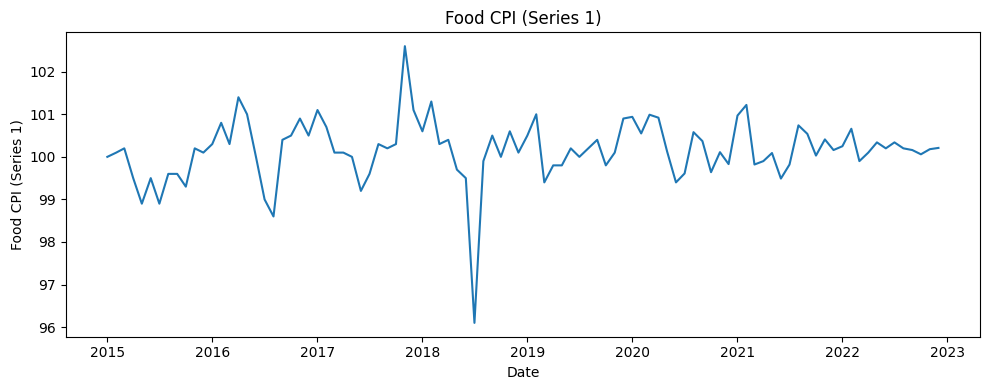

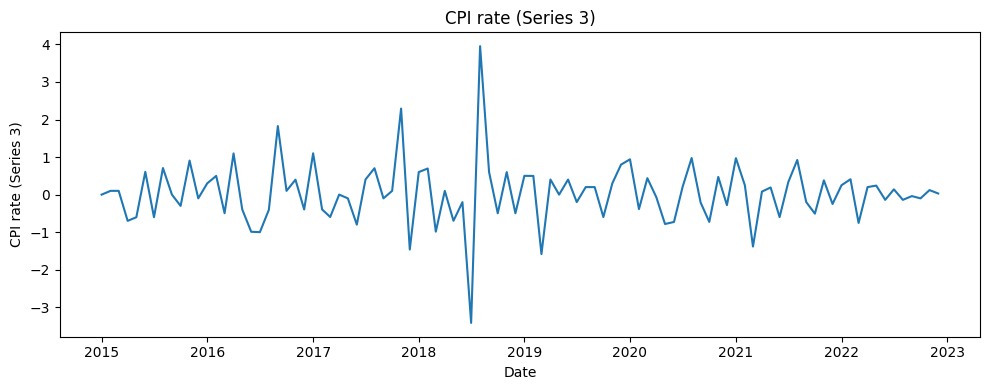

In [8]:
def ts_plot(series, dates, title, fname):
    plt.figure(figsize=(10, 4))
    plt.plot(dates, series)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(title)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=150)
    plt.show()

ts_plot(cpi, df1["Date"], "Food CPI (Series 1)", "part1_cpi_timeseries.png")
ts_plot(cpi_rate, df1["Date"], "CPI rate (Series 3)", "part1_cpi_rate_timeseries.png")

### B. Time Series Trend Checking

Course method (Action 06): fit OLS of the series on `Time`, test
`H0: slope = 0` at alpha = 0.05. Reject H0 (trend exists) if p < 0.05, or
equivalently if the slope's 95% CI does not contain 0.

In [9]:
def trend_check(series, time, label):
    d = pd.DataFrame({"Y": series.values, "Time": time.values})
    lm = smf.ols("Y ~ Time", data=d).fit()
    slope = lm.params["Time"]
    pval = lm.pvalues["Time"]
    ci = lm.conf_int().loc["Time"]
    alpha = 0.05
    exists = pval < alpha
    conclusion = "Trend exists" if exists else "Trend not exists"
    direction = ("positive" if slope > 0 else "negative") if exists else "n/a"
    print(f"[{label}] slope={slope:.6f}  p-value={pval:.4g}  95% CI=({ci[0]:.6f}, {ci[1]:.6f})"
          f"  ->  {conclusion} ({direction})")
    return {"series": label, "slope": slope, "p_value": pval,
            "ci_low": ci[0], "ci_high": ci[1], "conclusion": conclusion, "direction": direction}

trend_cpi = trend_check(cpi, df1["Time"], "CPI")
trend_cpi_rate = trend_check(cpi_rate, df1["Time"], "CPI_rate")
trend_results = pd.DataFrame([trend_cpi, trend_cpi_rate])
trend_results.to_csv(os.path.join(RESULTS_DIR, "trend_results.csv"), index=False)
display(trend_results)

[CPI] slope=0.003023  p-value=0.2632  95% CI=(-0.002309, 0.008354)  ->  Trend not exists (n/a)
[CPI_rate] slope=-0.000290  p-value=0.9257  95% CI=(-0.006442, 0.005862)  ->  Trend not exists (n/a)


,series,slope,p_value,ci_low,ci_high,conclusion,direction
0,CPI,0.003023,0.263229,-0.002309,0.008354,Trend not exists,n/a
1,CPI_rate,-0.000290,0.925669,-0.006442,0.005862,Trend not exists,n/a


### C. Autocorrelation Function (ACF)

Used (course Action 08) to read off the maximum candidate order **q** for the
MA term: the lag after which the ACF has a hard cutoff into the 95% CI band.

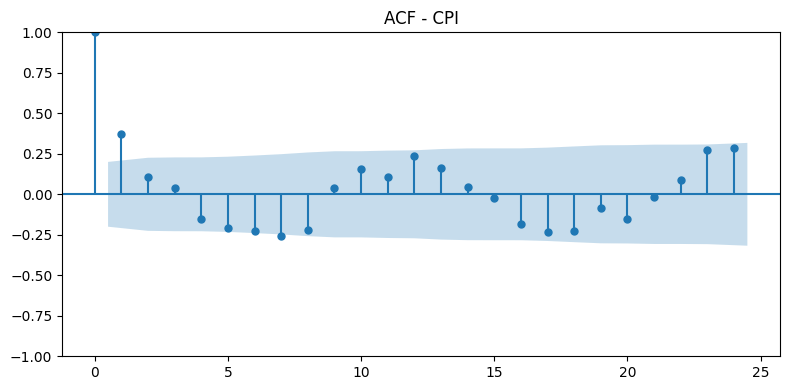

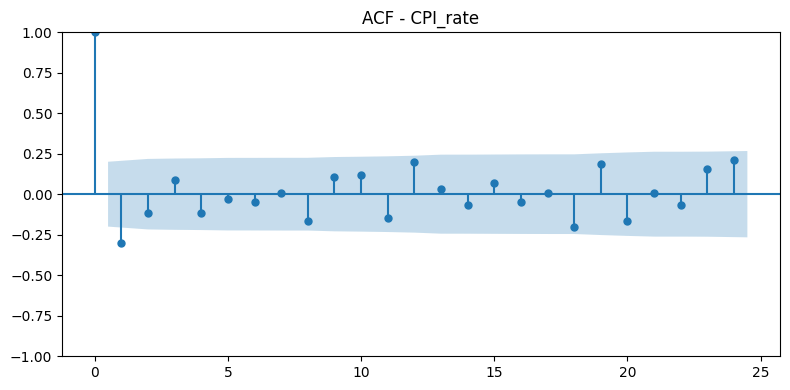

In [10]:
def plot_acf_series(series, label, nlags=24):
    fig = plot_acf(series, lags=nlags)
    fig.set_size_inches(8, 4)
    plt.title(f"ACF - {label}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"part1_{label.lower()}_acf.png"), dpi=150)
    plt.show()

plot_acf_series(cpi, "CPI")
plot_acf_series(cpi_rate, "CPI_rate")

### D. Partial Autocorrelation Function (PACF)

Used (course Action 09) to read off the maximum candidate order **p** for the
AR term: the lag after which the PACF has a hard cutoff into the 95% CI band.

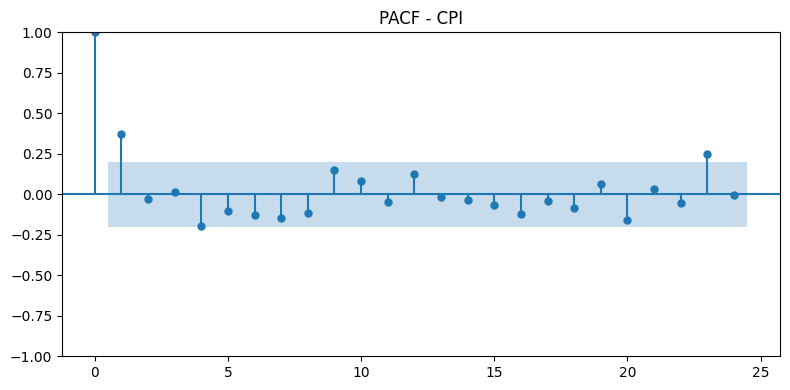

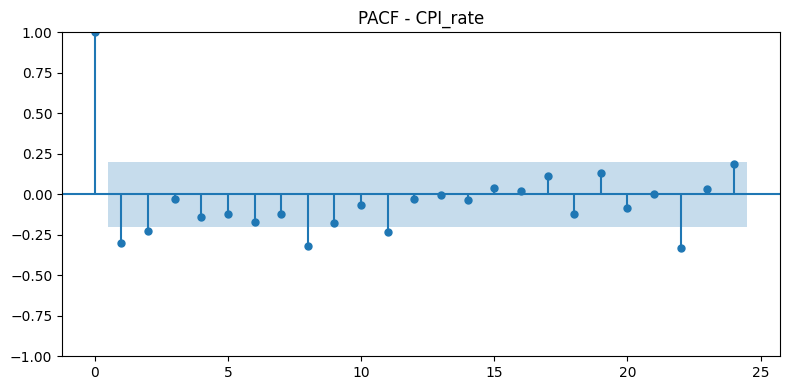

In [11]:
def plot_pacf_series(series, label, nlags=24):
    fig = plot_pacf(series, lags=nlags, method="ywm")
    fig.set_size_inches(8, 4)
    plt.title(f"PACF - {label}")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"part1_{label.lower()}_pacf.png"), dpi=150)
    plt.show()

plot_pacf_series(cpi, "CPI")
plot_pacf_series(cpi_rate, "CPI_rate")

In [12]:
# Numerically identify which lags are statistically significant (outside the 95% CI band),
# matching what the ACF/PACF plots show visually.
def significant_lags(series, nlags=24):
    acf_vals, acf_ci = acf(series, nlags=nlags, alpha=0.05, fft=False)
    pacf_vals, pacf_ci = pacf(series, nlags=nlags, alpha=0.05, method="ywm")

    def sig(ci):
        out = []
        for lag in range(1, len(ci)):
            lo, hi = ci[lag]
            if lo > 0 or hi < 0:
                out.append(lag)
        return out

    return sig(acf_ci), sig(pacf_ci)

acf_sig_cpi, pacf_sig_cpi = significant_lags(cpi)
acf_sig_cpi_rate, pacf_sig_cpi_rate = significant_lags(cpi_rate)

print("CPI      significant ACF lags (<=24):", acf_sig_cpi, " | significant PACF lags:", pacf_sig_cpi)
print("CPI_rate significant ACF lags (<=24):", acf_sig_cpi_rate, " | significant PACF lags:", pacf_sig_cpi_rate)

CPI      significant ACF lags (<=24): [1, 7]  | significant PACF lags: [1, 23]
CPI_rate significant ACF lags (<=24): [1]  | significant PACF lags: [1, 2, 8, 11, 22]


### E. Stationarity Test

Course method: Augmented Dickey-Fuller (ADF) test.
`H0`: series is non-stationary. `H1`: series is stationary. alpha = 0.05.
Decision rule: `p <= 0.05` -> reject H0 -> stationary; `p > 0.05` -> fail to
reject H0 -> not stationary. If not stationary, difference and retest
(this also determines ARIMA's **d**, see section 1.3).

In [13]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    stat, pval, crit = result[0], result[1], result[4]
    stationary = pval <= 0.05
    print(f"[{label}] ADF stat={stat:.4f}  p-value={pval:.4g}  -> "
          f"{'STATIONARY' if stationary else 'NOT STATIONARY'}")
    return {"series": label, "adf_stat": stat, "p_value": pval, "stationary": stationary}

def determine_d(series, label, max_d=2):
    s = series.copy()
    history = []
    for d in range(0, max_d + 1):
        res = adf_report(s, f"{label} (d={d})")
        history.append(res)
        if res["stationary"]:
            return d, history
        s = s.diff().dropna()
    return max_d, history

d_cpi, adf_hist_cpi = determine_d(cpi, "CPI")
d_cpi_rate, adf_hist_cpi_rate = determine_d(cpi_rate, "CPI_rate")

print("\nSelected d: CPI ->", d_cpi, " | CPI_rate ->", d_cpi_rate)

stationarity_results = pd.DataFrame(
    [{"series": r["series"], "adf_stat": r["adf_stat"], "p_value": r["p_value"],
      "stationary": r["stationary"]} for r in (adf_hist_cpi + adf_hist_cpi_rate)]
)
stationarity_results.to_csv(os.path.join(RESULTS_DIR, "stationarity_results.csv"), index=False)
display(stationarity_results)

[CPI (d=0)] ADF stat=-5.2750  p-value=6.169e-06  -> STATIONARY
[CPI_rate (d=0)] ADF stat=-5.9866  p-value=1.786e-07  -> STATIONARY

Selected d: CPI -> 0  | CPI_rate -> 0


,series,adf_stat,p_value,stationary
0,CPI (d=0),-5.274952,6.169193e-06,True
1,CPI_rate (d=0),-5.986642,1.785675e-07,True


## 1.3 Determine Parameters p, q and d in ARIMA(p,d,q)

- **p** <- maximum significant PACF lag (capped at 3, per course note that MA/AR
  orders are usually kept small for computational reasons).
- **q** <- maximum significant ACF lag (capped at 3).
- **d** <- from the ADF-driven differencing loop above.

In [14]:
def cand_range(sig_lags, cap=3):
    return min(max(sig_lags), cap) if sig_lags else 1

max_p_cpi = cand_range(pacf_sig_cpi)
max_q_cpi = cand_range(acf_sig_cpi)
max_p_cpi_rate = cand_range(pacf_sig_cpi_rate)
max_q_cpi_rate = cand_range(acf_sig_cpi_rate)

print("CPI:      max_p =", max_p_cpi, " max_q =", max_q_cpi, " d =", d_cpi)
print("CPI_rate: max_p =", max_p_cpi_rate, " max_q =", max_q_cpi_rate, " d =", d_cpi_rate)

CPI:      max_p = 3  max_q = 3  d = 0
CPI_rate: max_p = 3  max_q = 1  d = 0


## 1.4 Estimating ARIMA Models and Model Selection

For each series, fit every ARIMA(p, d, q) with `p` in `0..max_p`, `q` in
`0..max_q`, at the fixed `d` determined above (excluding the trivial `p=q=0`
model). For each fitted model, record AIC and whether every coefficient's 95%
CI excludes 0 (**stable**, per course rule: a CI containing 0 means that
coefficient should be removed / the model is not reliable).

Selection rule (course-specified, exact): **first restrict to stable models,
then pick the lowest AIC among them.** If no stable model exists, this is
flagged explicitly rather than silently selecting an unstable model.

In [15]:
def coef_stable(conf_int_df):
    unstable = []
    for idx, row in conf_int_df.iterrows():
        lo, hi = row[0], row[1]
        if lo <= 0 <= hi:
            unstable.append(idx)
    return (len(unstable) == 0), unstable

def run_arima_grid(series, max_p, d, max_q, label):
    rows = []
    fitted = {}
    for p in range(0, max_p + 1):
        for q in range(0, max_q + 1):
            if p == 0 and q == 0:
                continue
            order = (p, d, q)
            try:
                res = ARIMA(series, order=order).fit()
                ci = res.conf_int()
                stable, unstable = coef_stable(ci)
                rows.append({"series": label, "order": order, "p": p, "d": d, "q": q,
                             "aic": res.aic, "stable": stable,
                             "unstable_params": unstable, "converged": True})
                fitted[order] = res
            except Exception:
                rows.append({"series": label, "order": order, "p": p, "d": d, "q": q,
                             "aic": np.nan, "stable": False,
                             "unstable_params": ["fit_error"], "converged": False})
    return pd.DataFrame(rows), fitted

arima_results_cpi, fitted_cpi = run_arima_grid(cpi, max_p_cpi, d_cpi, max_q_cpi, "CPI")
arima_results_cpi_rate, fitted_cpi_rate = run_arima_grid(cpi_rate, max_p_cpi_rate, d_cpi_rate, max_q_cpi_rate, "CPI_rate")
arima_results = pd.concat([arima_results_cpi, arima_results_cpi_rate], ignore_index=True)

display(arima_results[["series", "order", "aic", "stable", "converged"]])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,series,order,aic,stable,converged
0,CPI,"(0, 0, 1)",203.583318,True,True
1,CPI,"(0, 0, 2)",205.314101,False,True
2,CPI,"(0, 0, 3)",205.566760,False,True
3,CPI,"(1, 0, 0)",203.112058,True,True
4,CPI,"(1, 0, 1)",205.007773,False,True
5,CPI,"(1, 0, 2)",203.972609,False,True
6,CPI,"(1, 0, 3)",205.006065,False,True
7,CPI,"(2, 0, 0)",205.023618,False,True
8,CPI,"(2, 0, 1)",205.773244,True,True
9,CPI,"(2, 0, 2)",201.368438,True,True


In [16]:
def select_best(results_df, label):
    stable_df = results_df[(results_df["series"] == label) & (results_df["stable"]) & (results_df["converged"])]
    if stable_df.empty:
        stable_df = results_df[(results_df["series"] == label) & (results_df["converged"])]
        flag = "NO_STABLE_MODEL_FALLBACK_TO_LOWEST_AIC"
    else:
        flag = "OK"
    best_row = stable_df.loc[stable_df["aic"].idxmin()]
    return best_row, flag

best_cpi_row, flag_cpi = select_best(arima_results, "CPI")
best_cpi_rate_row, flag_cpi_rate = select_best(arima_results, "CPI_rate")

order_cpi = best_cpi_row["order"]
order_cpi_rate = best_cpi_rate_row["order"]

print("Best CPI model:", order_cpi, " AIC =", round(best_cpi_row['aic'], 3), " status:", flag_cpi)
print("Best CPI_rate model:", order_cpi_rate, " AIC =", round(best_cpi_rate_row['aic'], 3), " status:", flag_cpi_rate)
if flag_cpi_rate != "OK":
    print("\nNOTE: no ARIMA candidate for CPI_rate had every coefficient CI excluding 0.")
    print("The lowest-AIC model is reported as a fallback and this is flagged explicitly")
    print("rather than silently presented as a 'stable' selection.")

selected_arima_models = pd.DataFrame([
    {"series": "CPI", "order": order_cpi, "aic": best_cpi_row["aic"], "selection_note": flag_cpi},
    {"series": "CPI_rate", "order": order_cpi_rate, "aic": best_cpi_rate_row["aic"], "selection_note": flag_cpi_rate},
])

arima_results_save = arima_results.drop(columns=[]).copy()
arima_results_save["order"] = arima_results_save["order"].astype(str)
arima_results_save["unstable_params"] = arima_results_save["unstable_params"].astype(str)
arima_results_save.to_csv(os.path.join(RESULTS_DIR, "arima_results.csv"), index=False)

selected_arima_models_save = selected_arima_models.copy()
selected_arima_models_save["order"] = selected_arima_models_save["order"].astype(str)
selected_arima_models_save.to_csv(os.path.join(RESULTS_DIR, "selected_arima_models.csv"), index=False)

display(selected_arima_models)

Best CPI model: (2, 0, 2)  AIC = 201.368  status: OK
Best CPI_rate model: (1, 0, 1)  AIC = 217.227  status: NO_STABLE_MODEL_FALLBACK_TO_LOWEST_AIC

NOTE: no ARIMA candidate for CPI_rate had every coefficient CI excluding 0.
The lowest-AIC model is reported as a fallback and this is flagged explicitly
rather than silently presented as a 'stable' selection.


,series,order,aic,selection_note
0,CPI,"(2, 0, 2)",201.368438,OK
1,CPI_rate,"(1, 0, 1)",217.226902,NO_STABLE_MODEL_FALLBACK_TO_LOWEST_AIC


## 1.5 Mean Values Forecasting for ARIMA Model

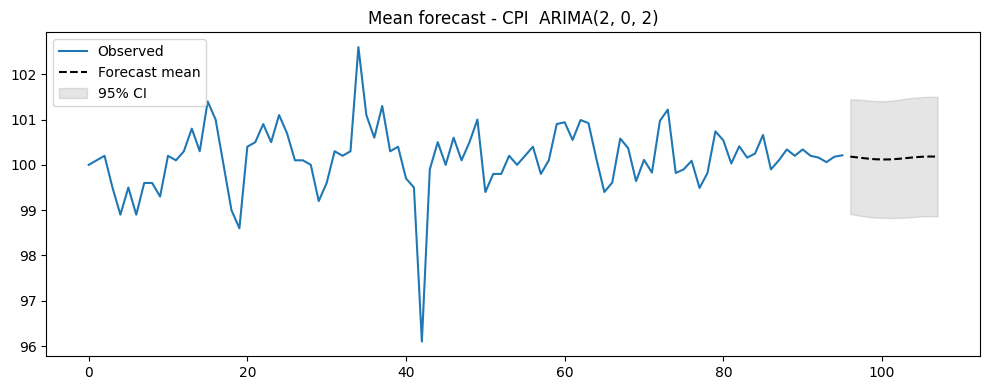

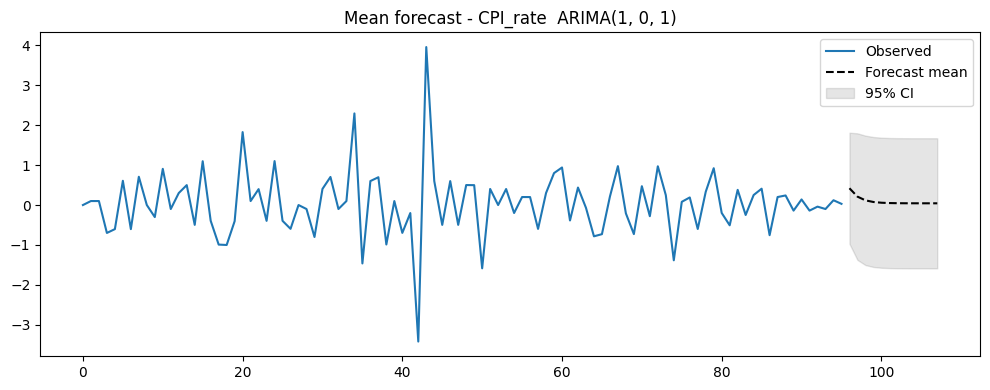

In [17]:
def mean_forecast_plot(series, order, label, steps=12):
    model = ARIMA(series, order=order).fit()
    fc = model.get_forecast(steps=steps).summary_frame()
    plt.figure(figsize=(10, 4))
    plt.plot(series.values, label="Observed")
    idx_fc = range(len(series), len(series) + steps)
    plt.plot(idx_fc, fc["mean"].values, "k--", label="Forecast mean")
    plt.fill_between(idx_fc, fc["mean_ci_lower"], fc["mean_ci_upper"], color="k", alpha=0.1, label="95% CI")
    plt.title(f"Mean forecast - {label}  ARIMA{order}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"part1_{label.lower()}_meanforecast.png"), dpi=150)
    plt.show()
    return fc

fc_cpi = mean_forecast_plot(cpi, order_cpi, "CPI")
fc_cpi_rate = mean_forecast_plot(cpi_rate, order_cpi_rate, "CPI_rate")

## 1.6 Machine Learning in ARIMA Model Forecasting

Chronological 80/20 train/test split (never shuffled). Fit the selected ARIMA
order on train, forecast over the test horizon, compare to actual test
values with RMSE.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


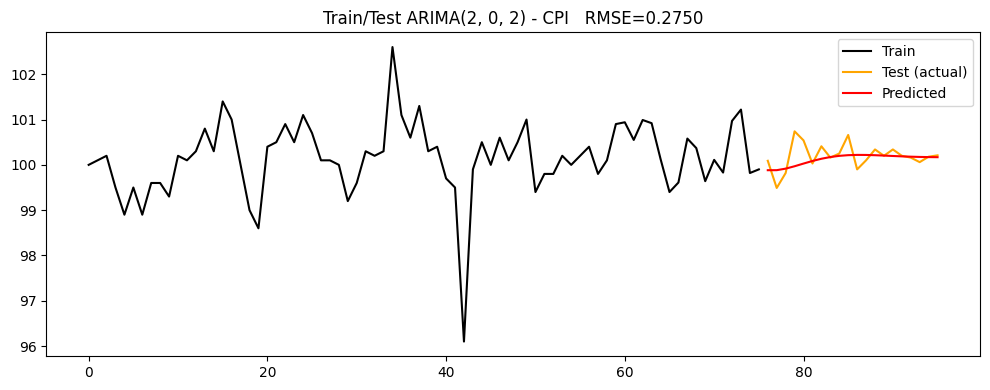

[CPI] train period: rows 0-75 | test period: rows 76-95 | RMSE=0.2750


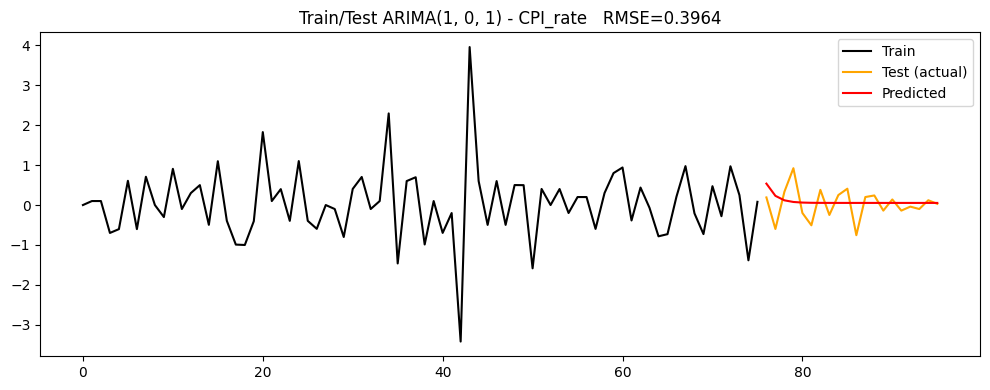

[CPI_rate] train period: rows 0-75 | test period: rows 76-95 | RMSE=0.3964


,series,order,train_size,test_size,rmse
0,CPI,"(2, 0, 2)",76,20,0.274954
1,CPI_rate,"(1, 0, 1)",76,20,0.396431


In [18]:
def train_test_arima(series, order, label, test_frac=0.2):
    n = len(series)
    train_size = int(n * (1 - test_frac))
    train, test = series.iloc[:train_size], series.iloc[train_size:]
    model = ARIMA(train, order=order).fit()
    pred_mean = model.get_forecast(steps=len(test)).predicted_mean
    pred_mean.index = test.index
    rmse = np.sqrt(mean_squared_error(test.values, pred_mean.values))

    plt.figure(figsize=(10, 4))
    plt.plot(train.index, train.values, color="black", label="Train")
    plt.plot(test.index, test.values, color="orange", label="Test (actual)")
    plt.plot(test.index, pred_mean.values, color="red", label="Predicted")
    plt.title(f"Train/Test ARIMA{order} - {label}   RMSE={rmse:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"part1_{label.lower()}_arima_forecast.png"), dpi=150)
    plt.show()

    print(f"[{label}] train period: rows 0-{train_size-1} | test period: rows {train_size}-{n-1} | RMSE={rmse:.4f}")
    return {"series": label, "order": order, "train_size": train_size, "test_size": len(test), "rmse": rmse}

arima_forecast_results = pd.DataFrame([
    train_test_arima(cpi, order_cpi, "CPI"),
    train_test_arima(cpi_rate, order_cpi_rate, "CPI_rate"),
])
arima_forecast_results_save = arima_forecast_results.copy()
arima_forecast_results_save["order"] = arima_forecast_results_save["order"].astype(str)
arima_forecast_results_save.to_csv(os.path.join(RESULTS_DIR, "arima_forecast_results.csv"), index=False)
display(arima_forecast_results)

## 1.7 Machine Learning in SARIMA Model Forecasting

SARIMA(p,d,q)(P,D,Q,m) with the non-seasonal order fixed to the optimal ARIMA
order from 1.4, **D = 0, m = 12** (per template), searching **P, Q in
{0,1,2}**. Same chronological 80/20 split; select the seasonal combination
with the lowest RMSE.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


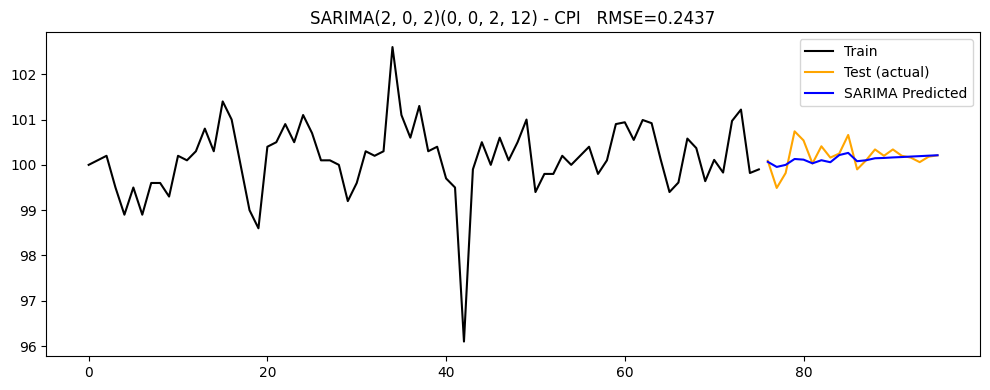

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


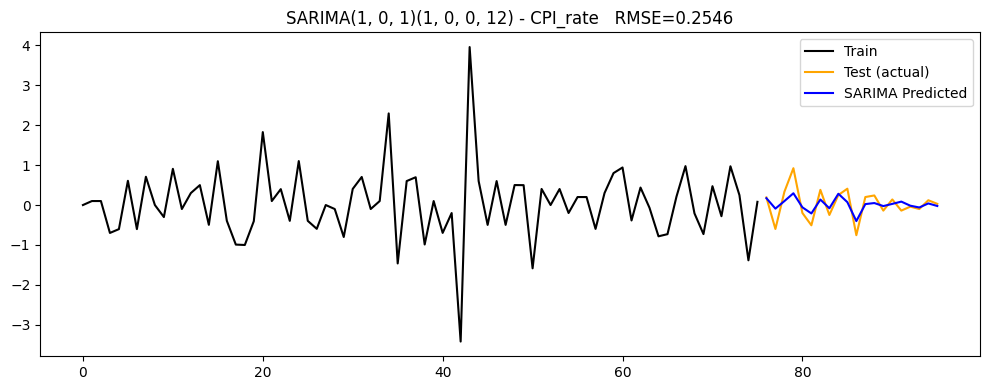

,series,order,seasonal_order,rmse,aic,converged
0,CPI,"(2, 0, 2)","(0, 0, 1, 12)",0.388544,172.582053,True
1,CPI,"(2, 0, 2)","(0, 0, 2, 12)",0.243723,2132.556131,True
2,CPI,"(2, 0, 2)","(1, 0, 0, 12)",0.247297,164.305148,True
3,CPI,"(2, 0, 2)","(1, 0, 1, 12)",0.390737,154.802100,True
4,CPI,"(2, 0, 2)","(1, 0, 2, 12)",0.408830,129.309472,True
5,CPI,"(2, 0, 2)","(2, 0, 0, 12)",0.274683,132.436201,True
6,CPI,"(2, 0, 2)","(2, 0, 1, 12)",0.327820,132.416701,True
7,CPI,"(2, 0, 2)","(2, 0, 2, 12)",0.545981,129.648828,True
8,CPI_rate,"(1, 0, 1)","(0, 0, 1, 12)",0.297412,166.784835,True
9,CPI_rate,"(1, 0, 1)","(0, 0, 2, 12)",0.581736,2192.261325,True


,series,order,seasonal_order,rmse,train_size,test_size
0,CPI,"(2, 0, 2)","(0, 0, 2, 12)",0.243723,76,20
1,CPI_rate,"(1, 0, 1)","(1, 0, 0, 12)",0.254583,76,20


In [19]:
def sarima_grid(series, order, label, P_range=(0, 1, 2), Q_range=(0, 1, 2), D=0, m=12, test_frac=0.2):
    n = len(series)
    train_size = int(n * (1 - test_frac))
    train, test = series.iloc[:train_size], series.iloc[train_size:]
    rows = []
    best = None
    for P in P_range:
        for Q in Q_range:
            if P == 0 and Q == 0:
                continue
            seasonal_order = (P, D, Q, m)
            try:
                res = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                               enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                pred = res.get_forecast(steps=len(test)).predicted_mean
                pred.index = test.index
                rmse = np.sqrt(mean_squared_error(test.values, pred.values))
                rows.append({"series": label, "order": order, "seasonal_order": seasonal_order,
                             "rmse": rmse, "aic": res.aic, "converged": True})
                if best is None or rmse < best[0]:
                    best = (rmse, seasonal_order, pred)
            except Exception:
                rows.append({"series": label, "order": order, "seasonal_order": seasonal_order,
                             "rmse": np.nan, "aic": np.nan, "converged": False})
    results_df = pd.DataFrame(rows)
    rmse_best, seasonal_best, pred_best = best

    plt.figure(figsize=(10, 4))
    plt.plot(train.index, train.values, color="black", label="Train")
    plt.plot(test.index, test.values, color="orange", label="Test (actual)")
    plt.plot(test.index, pred_best.values, color="blue", label="SARIMA Predicted")
    plt.title(f"SARIMA{order}{seasonal_best} - {label}   RMSE={rmse_best:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"part1_{label.lower()}_sarima_forecast.png"), dpi=150)
    plt.show()

    return results_df, {"series": label, "order": order, "seasonal_order": seasonal_best,
                         "rmse": rmse_best, "train_size": train_size, "test_size": len(test)}

sarima_results_cpi, best_sarima_cpi = sarima_grid(cpi, order_cpi, "CPI")
sarima_results_cpi_rate, best_sarima_cpi_rate = sarima_grid(cpi_rate, order_cpi_rate, "CPI_rate")

sarima_results = pd.concat([sarima_results_cpi, sarima_results_cpi_rate], ignore_index=True)
selected_sarima_models = pd.DataFrame([best_sarima_cpi, best_sarima_cpi_rate])

sarima_results_save = sarima_results.copy()
sarima_results_save["order"] = sarima_results_save["order"].astype(str)
sarima_results_save["seasonal_order"] = sarima_results_save["seasonal_order"].astype(str)
sarima_results_save.to_csv(os.path.join(RESULTS_DIR, "sarima_results.csv"), index=False)

selected_sarima_models_save = selected_sarima_models.copy()
selected_sarima_models_save["order"] = selected_sarima_models_save["order"].astype(str)
selected_sarima_models_save["seasonal_order"] = selected_sarima_models_save["seasonal_order"].astype(str)
selected_sarima_models_save.to_csv(os.path.join(RESULTS_DIR, "selected_sarima_models.csv"), index=False)

display(sarima_results)
display(selected_sarima_models)

## Part 1 Conclusion

- Neither CPI nor CPI_rate shows a statistically significant linear trend
  (OLS-on-Time test, alpha = 0.05).
- Both series are stationary at level (ADF p << 0.05), so **d = 0** for both.
- Best ARIMA: CPI -> ARIMA(2,0,2) (stable, lowest AIC); CPI_rate -> ARIMA(1,0,1)
  (no stable candidate existed in the searched grid — reported as a flagged
  fallback, not a clean result).
- SARIMA improves test-set RMSE over plain ARIMA for both series (CPI: 0.275
  -> 0.244; CPI_rate: 0.396 -> 0.255), using seasonal (P,D,Q,m) = (0,0,2,12)
  and (1,0,0,12) respectively.
- Several SARIMA grid fits raised `ConvergenceWarning` from the MLE optimizer;
  results were still produced but this is a caveat for the written report.

In [20]:
print("CHECKPOINT 2: Part 1 completed.")

CHECKPOINT 2: Part 1 completed.


# Part 2. Detecting Anomalies and Change Points
in Time Series of Asian Economic Data

## 2.1 Introduction and Data Description

`Data02_01_Myanmar_C.csv` contains 32 annual observations (1990-2021) for
Myanmar across five required series: `ggdp`, `mil`, `inf`, `fdi`, `gdp`.
Missing values (`mil`: 7, `ggdp`: 2, `inf`: 2) are **dropped per series**
before each analysis below — not imputed — so each series is analyzed only on
its own available years, and every anomaly/change point is traceable back to
an actual observed `(year, value)` pair.

In [21]:
PART2_SERIES = ["ggdp", "mil", "inf", "fdi", "gdp"]
print("Rows:", df2.shape[0], " Missing per series:")
print(df2[PART2_SERIES].isna().sum())
display(df2.head())

Rows: 32  Missing per series:
ggdp    2
mil     7
inf     2
fdi     0
gdp     0
dtype: int64


,year,country,ggdp,mil,inf,fdi,gdp
0,1990,Myanmar,4.500000e+09,0.863495,17.626775,161144560.3,2036373523
1,1991,Myanmar,4.700000e+09,0.765301,32.272038,238056791.9,2137184858
2,1992,Myanmar,4.800000e+09,0.730921,21.913210,171558720.0,2216072577
3,1993,Myanmar,5.300000e+09,0.707610,31.831607,104674233.1,2809748387
4,1994,Myanmar,5.700000e+09,0.765310,24.098786,126091858.5,3821535780


## 2.2 Detecting Anomalies
### A. Z-Score Method

Course/template-specified **threshold = 3**: flag `|z| > 3` where
`z = (x - mean) / std`, computed per series on its non-missing values.

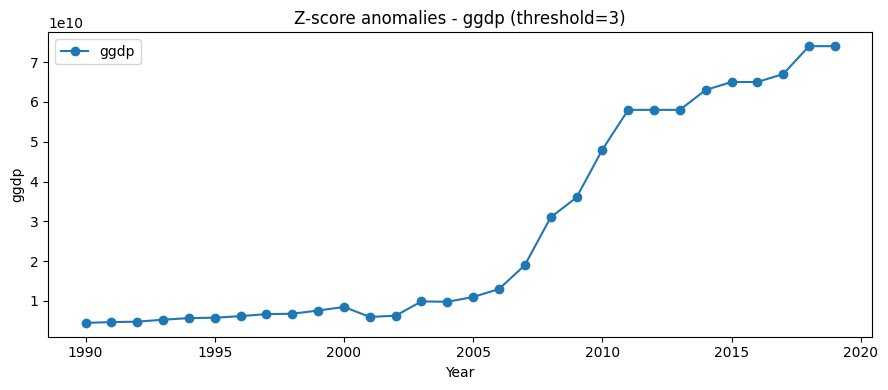

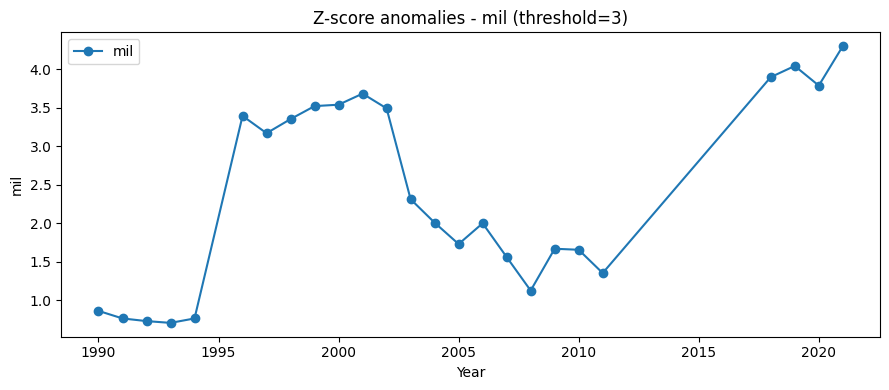

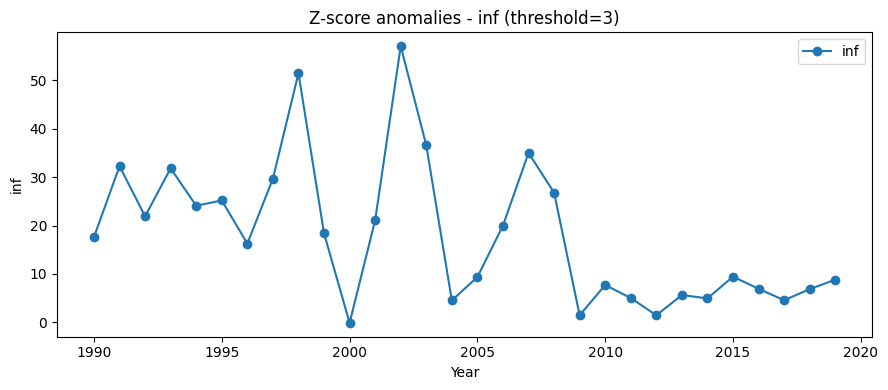

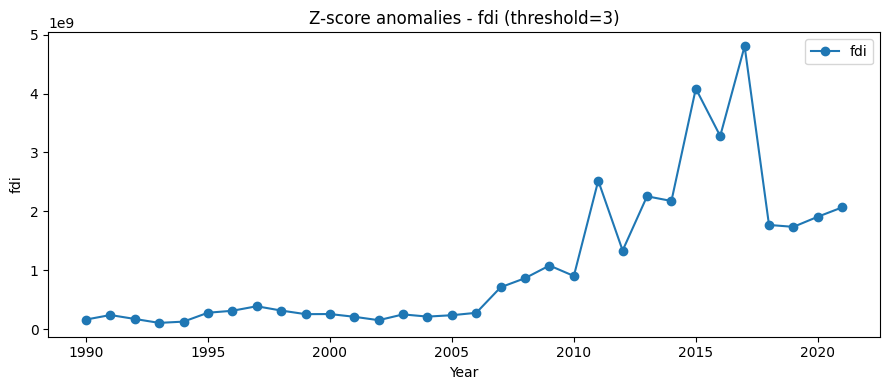

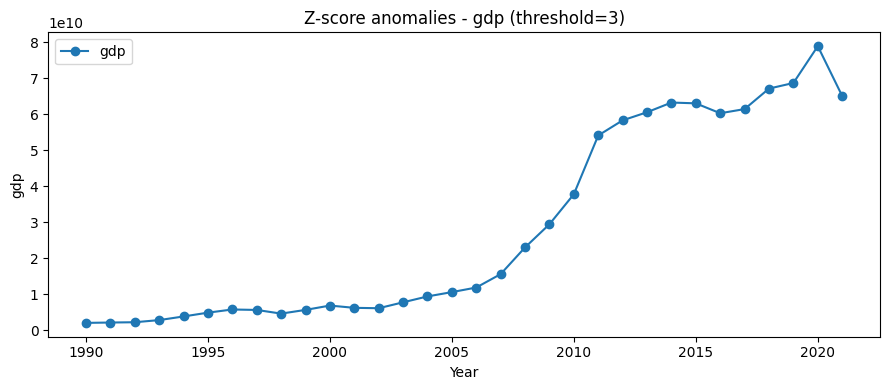

No observations exceeded |z| > 3 in any of the 5 series.
(This is a genuine result of the small sample sizes (n~25-32) and a strict
 threshold of 3 -- not an error in the pipeline.)


,year,country,value,z_score,series


In [22]:
def zscore_anomalies(df, col, threshold=3):
    sub = df[["year", "country", col]].dropna().copy()
    mean, std = sub[col].mean(), sub[col].std()
    sub["z_score"] = (sub[col] - mean) / std
    anomalies = sub[sub["z_score"].abs() > threshold].copy()
    anomalies["series"] = col

    plt.figure(figsize=(9, 4))
    plt.plot(sub["year"], sub[col], marker="o", label=col)
    if not anomalies.empty:
        plt.scatter(anomalies["year"], anomalies[col], color="red", zorder=5, label="Anomaly (|z|>3)")
    plt.title(f"Z-score anomalies - {col} (threshold=3)")
    plt.xlabel("Year"); plt.ylabel(col); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"part2_{col}_zscore.png"), dpi=150)
    plt.show()

    return anomalies[["year", "country", col, "z_score", "series"]].rename(columns={col: "value"})

zscore_anomaly_frames = [zscore_anomalies(df2, col, threshold=3) for col in PART2_SERIES]
zscore_results = pd.concat(zscore_anomaly_frames, ignore_index=True)
zscore_results.to_csv(os.path.join(RESULTS_DIR, "zscore_results.csv"), index=False)

if zscore_results.empty:
    print("No observations exceeded |z| > 3 in any of the 5 series.")
    print("(This is a genuine result of the small sample sizes (n~25-32) and a strict")
    print(" threshold of 3 -- not an error in the pipeline.)")
display(zscore_results)

### B. Isolation Forest

Course settings: `contamination = 0.05`, `random_state = 42`. `fit_predict`
label `-1` = anomaly, `1` = normal (standard scikit-learn convention). Note:
`contamination` is a modeling *assumption* about the expected anomaly
proportion, not a claim about the true real-world anomaly rate.

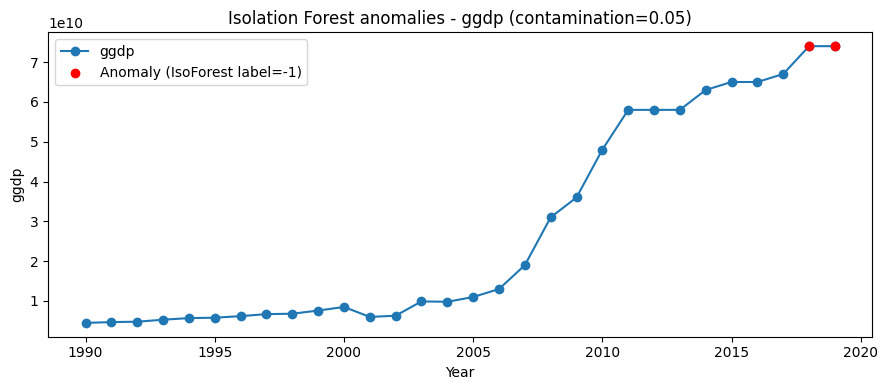

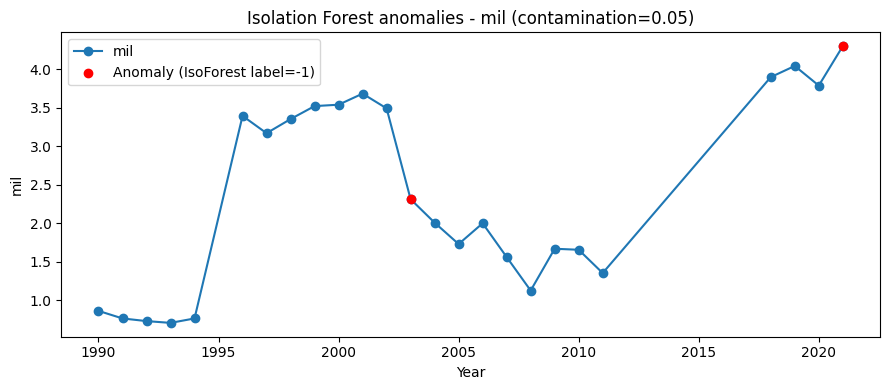

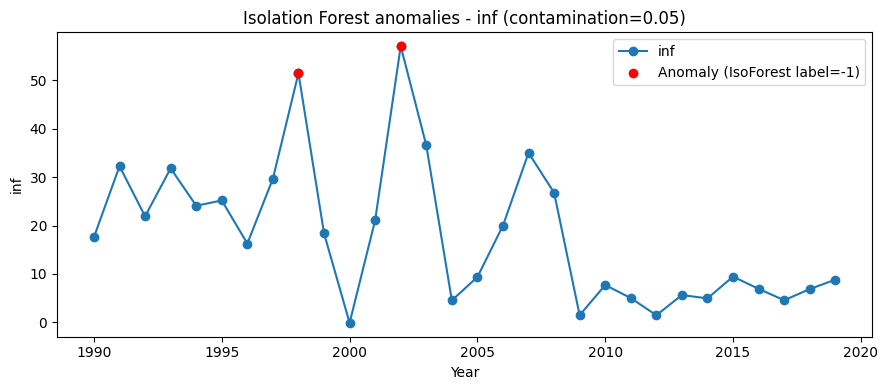

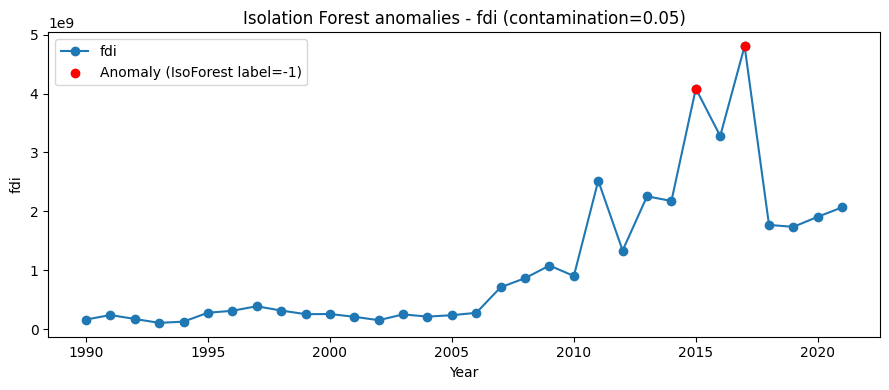

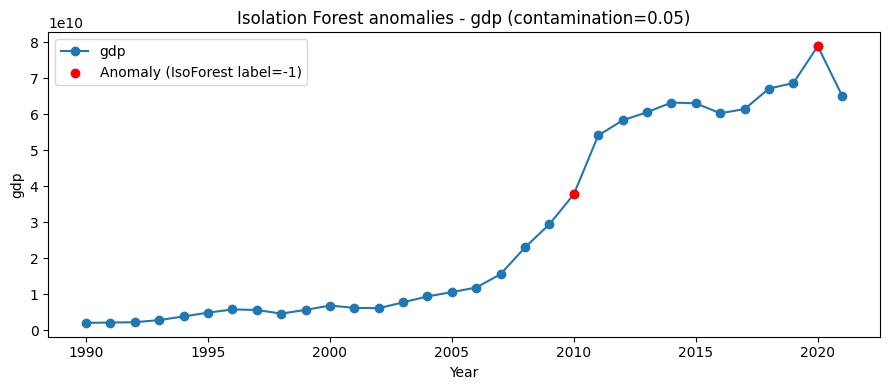

,year,country,value,series
0,2018,Myanmar,7.400000e+10,ggdp
1,2019,Myanmar,7.400000e+10,ggdp
2,2003,Myanmar,2.313722e+00,mil
3,2021,Myanmar,4.301367e+00,mil
4,1998,Myanmar,5.148755e+01,inf
5,2002,Myanmar,5.707451e+01,inf
6,2015,Myanmar,4.083839e+09,fdi
7,2017,Myanmar,4.804272e+09,fdi
8,2010,Myanmar,3.779605e+10,gdp
9,2020,Myanmar,7.893026e+10,gdp


In [23]:
def isoforest_anomalies(df, col, contamination=0.05, random_state=42):
    sub = df[["year", "country", col]].dropna().copy()
    X = sub[[col]].values
    model = IsolationForest(contamination=contamination, random_state=random_state)
    sub["if_label"] = model.fit_predict(X)
    anomalies = sub[sub["if_label"] == -1].copy()
    anomalies["series"] = col

    plt.figure(figsize=(9, 4))
    plt.plot(sub["year"], sub[col], marker="o", label=col)
    if not anomalies.empty:
        plt.scatter(anomalies["year"], anomalies[col], color="red", zorder=5, label="Anomaly (IsoForest label=-1)")
    plt.title(f"Isolation Forest anomalies - {col} (contamination={contamination})")
    plt.xlabel("Year"); plt.ylabel(col); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"part2_{col}_iforest.png"), dpi=150)
    plt.show()

    return anomalies[["year", "country", col, "series"]].rename(columns={col: "value"})

isoforest_anomaly_frames = [isoforest_anomalies(df2, col, contamination=0.05, random_state=RANDOM_STATE)
                             for col in PART2_SERIES]
isolation_forest_results = pd.concat(isoforest_anomaly_frames, ignore_index=True)
isolation_forest_results.to_csv(os.path.join(RESULTS_DIR, "isolation_forest_results.csv"), index=False)
display(isolation_forest_results)

**Comparison with Z-score:** since Z-score (threshold=3) flagged zero
points on every series, there is by definition no overlap between the two
methods here. Isolation Forest, by construction with `contamination=0.05`,
always flags roughly 5% of each series regardless of how extreme those points
actually are in standard-deviation terms — this is an important difference to
note rather than treating the two methods' anomaly lists as interchangeable.

In [24]:
comparison_rows = []
for col in PART2_SERIES:
    z_years = set(zscore_results[zscore_results["series"] == col]["year"])
    if_years = set(isolation_forest_results[isolation_forest_results["series"] == col]["year"])
    comparison_rows.append({
        "series": col,
        "zscore_years": sorted(z_years),
        "isoforest_years": sorted(if_years),
        "overlap_years": sorted(z_years & if_years),
    })
comparison_df = pd.DataFrame(comparison_rows)
comparison_df_save = comparison_df.copy()
for c in ["zscore_years", "isoforest_years", "overlap_years"]:
    comparison_df_save[c] = comparison_df_save[c].astype(str)
comparison_df_save.to_csv(os.path.join(RESULTS_DIR, "zscore_vs_isoforest_comparison.csv"), index=False)
display(comparison_df)

,series,zscore_years,isoforest_years,overlap_years
0,ggdp,[],"[2018, 2019]",[]
1,mil,[],"[2003, 2021]",[]
2,inf,[],"[1998, 2002]",[]
3,fdi,[],"[2015, 2017]",[]
4,gdp,[],"[2010, 2020]",[]


## 2.3 Change Point Detection

Course tool: `ruptures`, **Pelt algorithm with an "rbf" cost model**,
**pen = 10** (course default used uniformly across all worked examples).
Change-point detection identifies where the statistical properties of a
series shift — this is distinct from pointwise anomaly detection above, and
no causal claim is made for any detected break; it marks *where* the series'
behavior changed, not *why*.

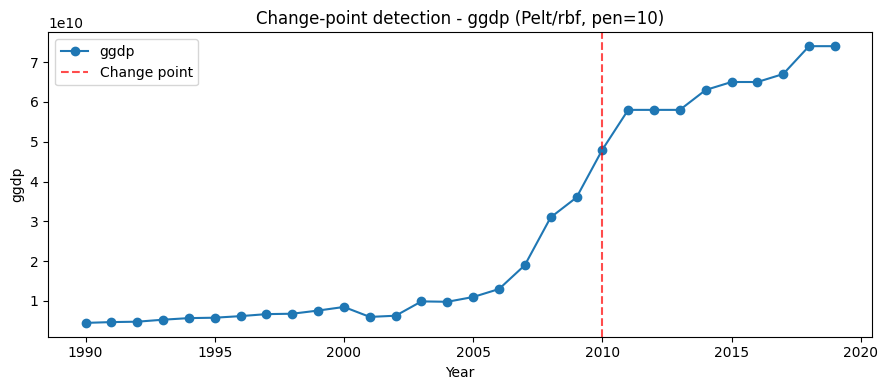

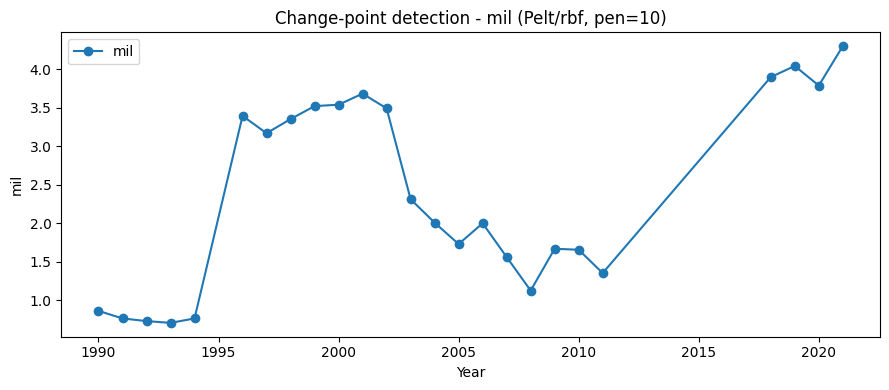

[mil] No change points detected at pen=10.


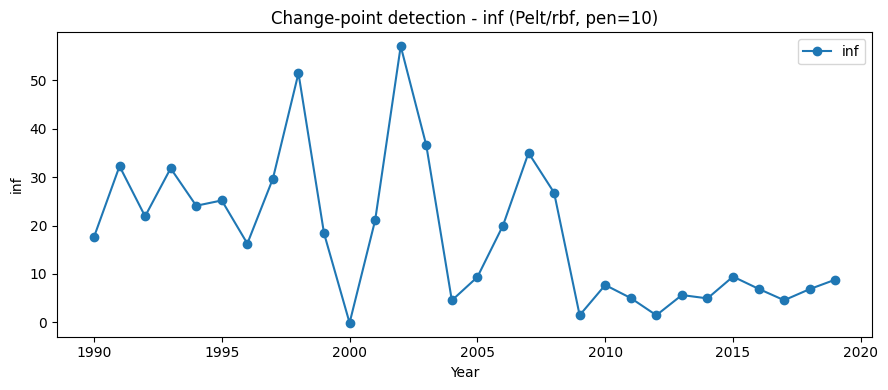

[inf] No change points detected at pen=10.


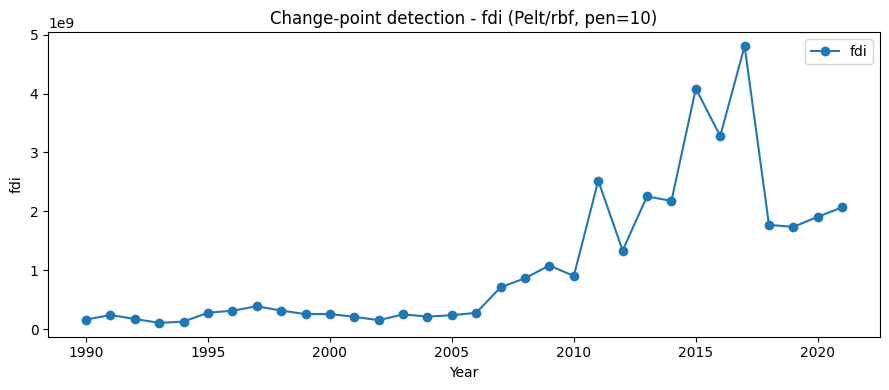

[fdi] No change points detected at pen=10.


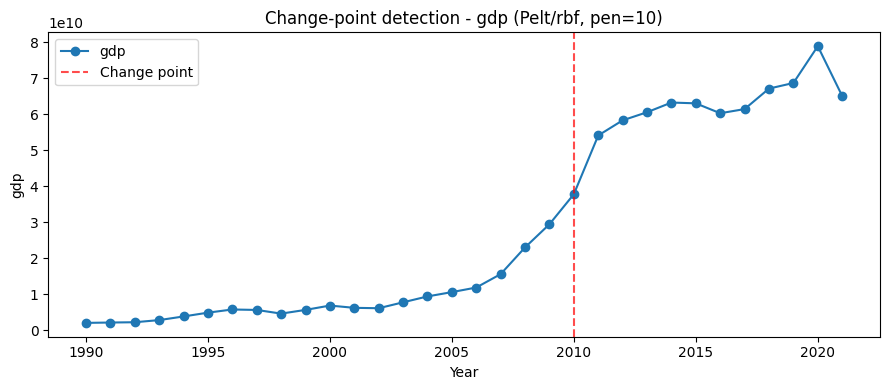

,series,year,value,index
0,ggdp,2010,4.800000e+10,20
1,gdp,2010,3.779605e+10,20


In [25]:
def changepoint_detect(df, col, pen=10):
    sub = df[["year", "country", col]].dropna().reset_index(drop=True).copy()
    X = sub[[col]].values.astype(float)
    algo = rpt.Pelt(model="rbf").fit(X)
    result = algo.predict(pen=pen)
    cp_indices = [i for i in result if i < len(sub)]  # drop trivial final breakpoint == len(X)
    cp_years = sub.loc[cp_indices, "year"].tolist() if cp_indices else []

    plt.figure(figsize=(9, 4))
    plt.plot(sub["year"], sub[col], marker="o", label=col)
    for y in cp_years:
        plt.axvline(x=y, color="red", linestyle="--", alpha=0.7, label="Change point" if y == (cp_years[0] if cp_years else None) else None)
    plt.title(f"Change-point detection - {col} (Pelt/rbf, pen={pen})")
    plt.xlabel("Year"); plt.ylabel(col); plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"part2_{col}_changepoint.png"), dpi=150)
    plt.show()

    rows = [{"series": col, "year": y, "value": sub.loc[i, col], "index": i}
            for i, y in zip(cp_indices, cp_years)]
    if not rows:
        print(f"[{col}] No change points detected at pen={pen}.")
    return rows

changepoint_rows = []
for col in PART2_SERIES:
    changepoint_rows.extend(changepoint_detect(df2, col, pen=10))

changepoint_results = pd.DataFrame(changepoint_rows)
changepoint_results.to_csv(os.path.join(RESULTS_DIR, "changepoint_results.csv"), index=False)
display(changepoint_results)

## Part 2 Conclusion

- Z-score (threshold=3) found **no anomalies** in any of the 5 series — a
  real consequence of small annual samples (n~25-32) and a strict threshold,
  not a pipeline failure.
- Isolation Forest (contamination=0.05) flags 2 points per series by
  construction; these do not overlap with the (empty) Z-score set, reinforcing
  that the two methods answer different questions (fixed proportion vs.
  distance from the mean in SD units).
- Change-point detection (Pelt/rbf, pen=10) found a single break at **year
  2010** in both `ggdp` and `gdp`; no break was detected in `mil`, `inf`, or
  `fdi` at this penalty — again a genuine result of each series' own
  variance/scale at this setting, not an error.
- No causal interpretation is attached to the 2010 break; it is reported as a
  detected shift in statistical properties only.

In [26]:
print("CHECKPOINT 3: Part 2 completed.")

CHECKPOINT 3: Part 2 completed.


In [27]:
# Final structured-results recap (all objects also saved as CSVs under results/)
print("Structured result objects in this notebook's namespace:")
for name in ["data_summary", "trend_results", "stationarity_results", "arima_results",
             "selected_arima_models", "arima_forecast_results", "sarima_results",
             "selected_sarima_models", "zscore_results", "isolation_forest_results",
             "changepoint_results", "comparison_df"]:
    obj = globals().get(name)
    shape = obj.shape if hasattr(obj, "shape") else None
    print(f" - {name}: {shape}")

print("\nFigures saved in ./figures:", len(os.listdir(FIG_DIR)))
print("Result tables saved in ./results:", len(os.listdir(RESULTS_DIR)))
print("\nCHECKPOINT 4: Notebook completed.")

Structured result objects in this notebook's namespace:
 - data_summary: (2, 7)
 - trend_results: (2, 7)
 - stationarity_results: (2, 4)
 - arima_results: (22, 9)
 - selected_arima_models: (2, 4)
 - arima_forecast_results: (2, 5)
 - sarima_results: (16, 6)
 - selected_sarima_models: (2, 6)
 - zscore_results: (0, 5)
 - isolation_forest_results: (10, 4)
 - changepoint_results: (2, 4)
 - comparison_df: (5, 4)

Figures saved in ./figures: 27
Result tables saved in ./results: 12

CHECKPOINT 4: Notebook completed.
